# Address Aggregation

Load the daily fused dataset, summarize across each address's active days
to create address-level profiles and remove highly correlated address level features

In [291]:
import pandas as pd
import numpy as np
import os
import json

In [292]:
daily_df = pd.read_parquet("../data/processed/final/daily_fused.parquet")

### Identify feature columns

In [293]:
# identify feature columns dynamically
onchain_raw = [c for c in daily_df.columns if not (c.startswith('market_') or c.startswith('reddit_') or c.startswith('twitter_') or c in ['address', 'day'])]
market_raw  = [c for c in daily_df.columns if c.startswith('market_')]
reddit_raw  = [c for c in daily_df.columns if c.startswith('reddit_')]
twitter_raw = [c for c in daily_df.columns if c.startswith('twitter_')]

### Aggregate to Address Level


In [294]:
# on-chain aggregation (mean, sum)
agg_dict = {'active_days': ('day', 'count')}
for col in onchain_raw:
    agg_dict[f'{col}_mean'] = (col, 'mean')
    agg_dict[f'{col}_max'] = (col, 'max')
    if 'sum' in col or 'flow' in col:
        agg_dict[f'{col}_total'] = (col, 'sum')

onchain_agg = daily_df.groupby('address').agg(**agg_dict).reset_index()
onchain_agg = onchain_agg.fillna(0)
onchain_features = [c for c in onchain_agg.columns if c != 'address']

# Off-chain aggregation (mean during active days)
offchain_agg_dict = {}
for col in market_raw + reddit_raw + twitter_raw:
    offchain_agg_dict[f'{col}_mean'] = (col, 'mean')

offchain_agg = daily_df.groupby('address').agg(**offchain_agg_dict).reset_index()
offchain_agg = offchain_agg.fillna(0)

# Regroup dynamically
market_features = [c for c in offchain_agg.columns if c.startswith('market_')]
reddit_features = [c for c in offchain_agg.columns if c.startswith('reddit_')]
twitter_features = [c for c in offchain_agg.columns if c.startswith('twitter_')]

### Load and merge is_scam labels at the address level

In [295]:
targets = pd.read_parquet("../data/processed/chain/targets_global.parquet")

targets_label = targets[['address', 'is_scam']].drop_duplicates('address')
onchain_agg['address'] = onchain_agg['address'].astype(str).str.lower()
targets_label['address'] = targets_label['address'].astype(str).str.lower()

# Merge On-chain + Off-chain + Label
address_df = onchain_agg.merge(offchain_agg, on='address', how='left').merge(targets_label, on='address', how='inner')

print(f"Address-level dataset shape: {address_df.shape}")
print(f"Scam addresses: {address_df['is_scam'].sum()}")
print(f"Normal addresses: {(address_df['is_scam'] == 0).sum()}")

Address-level dataset shape: (35272, 39)
Scam addresses: 5742
Normal addresses: 29530


### Feature Selection: Address Level

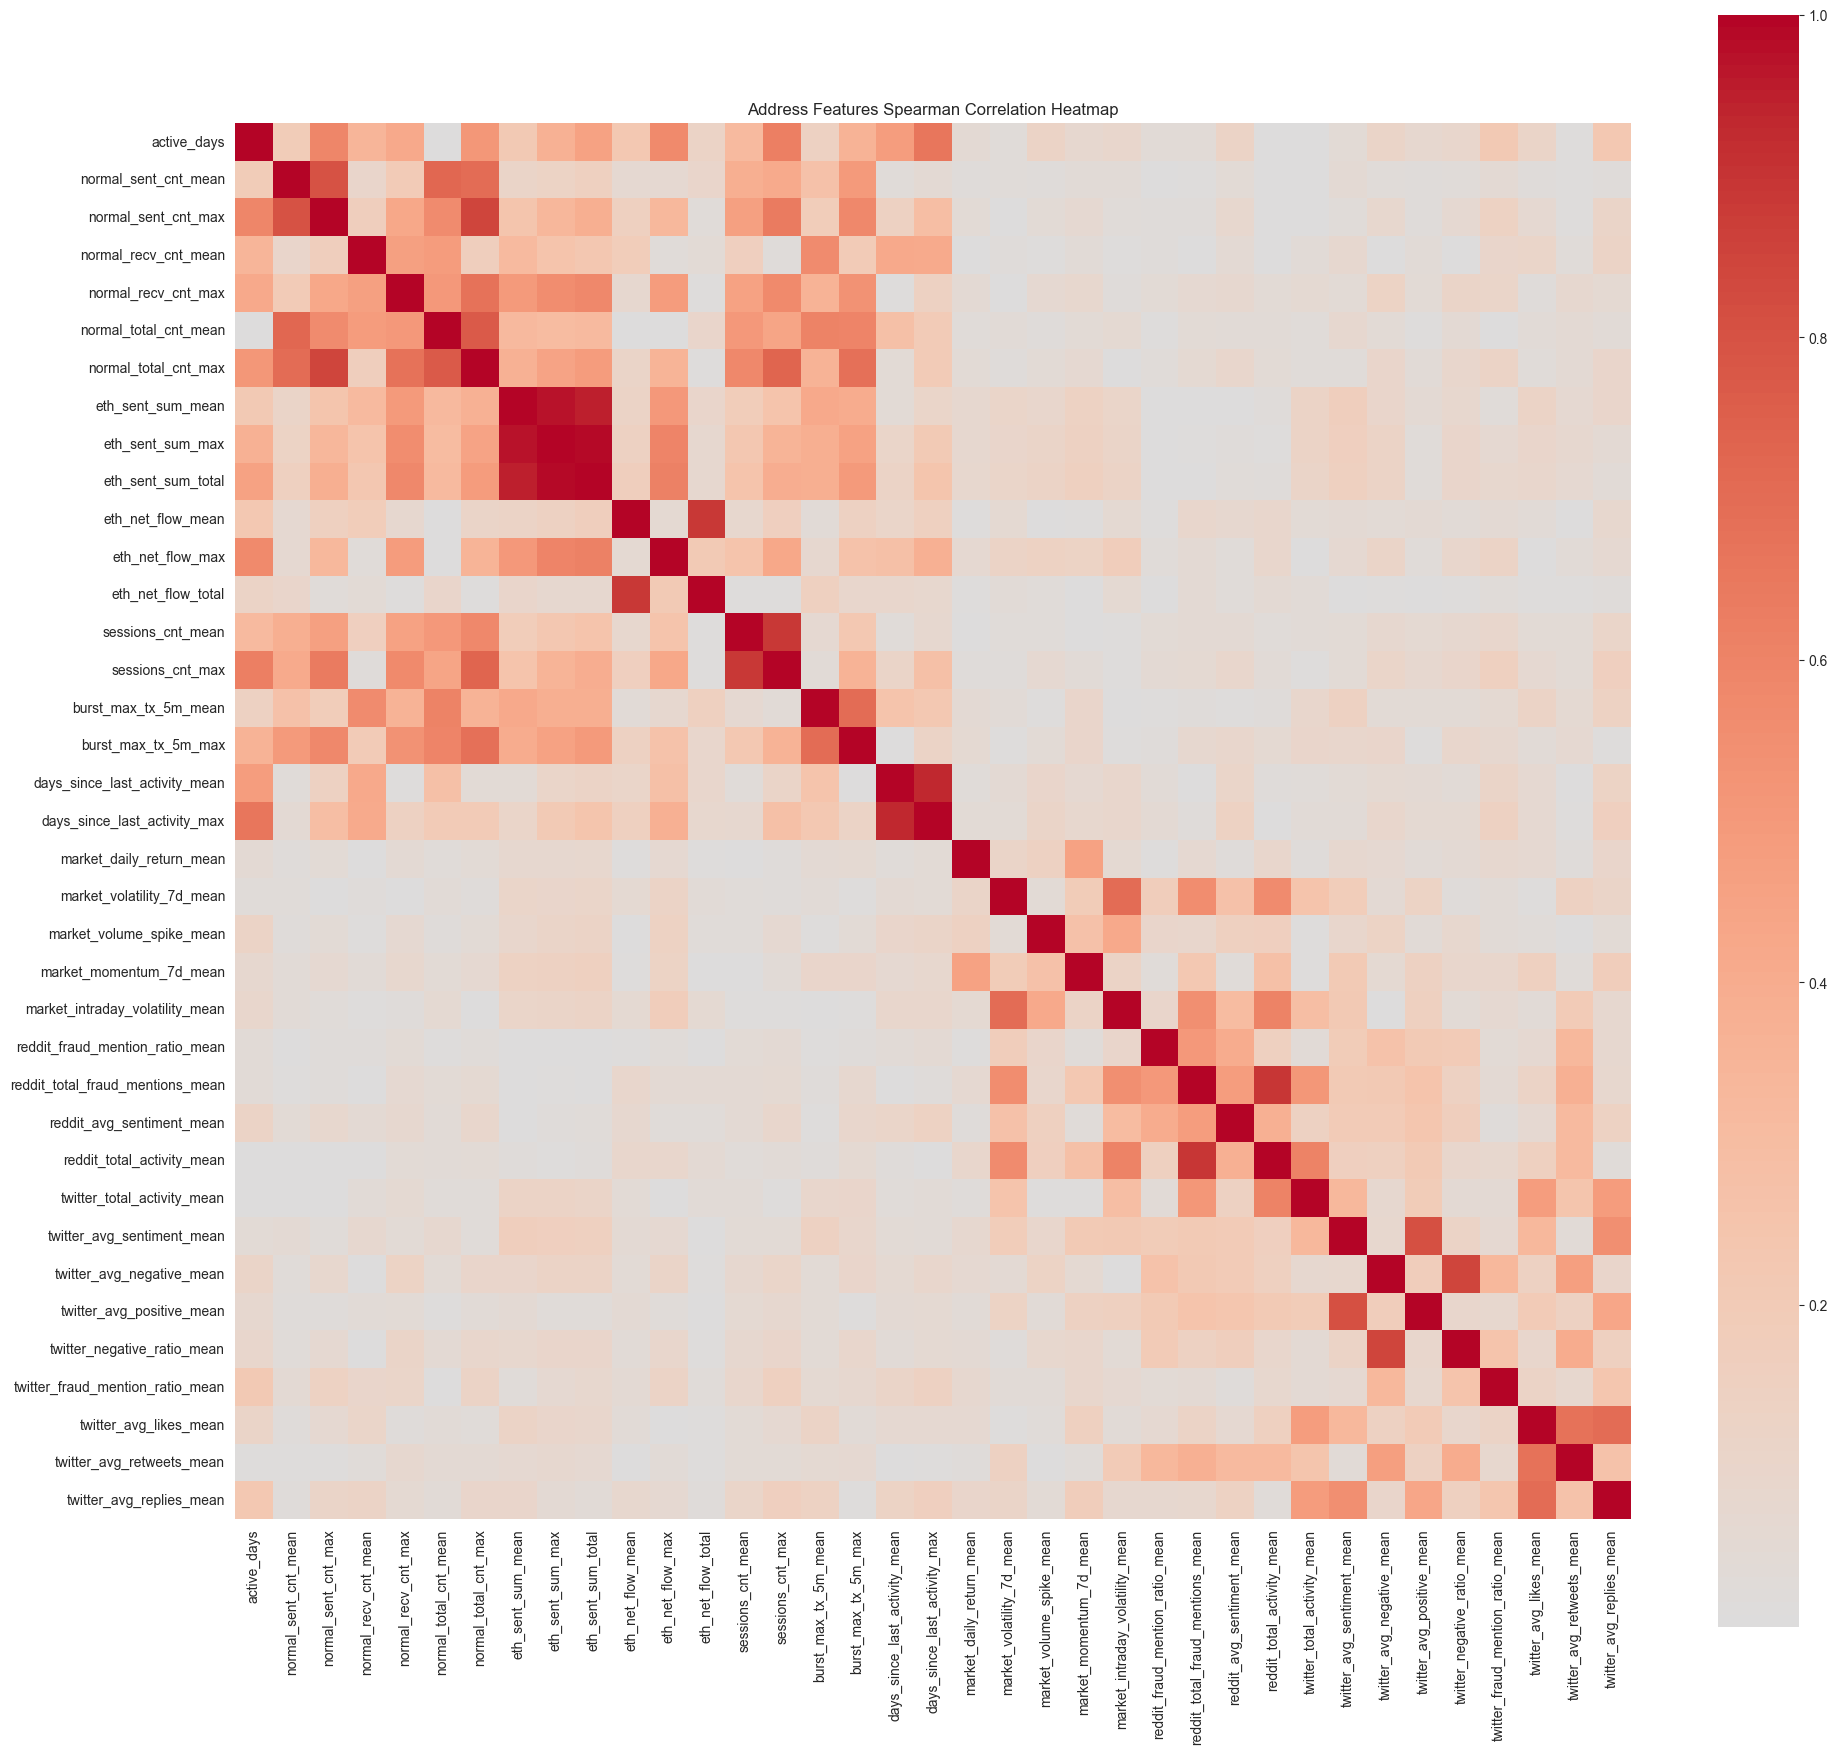

Dropping correlated address-level features (6):
  - eth_sent_sum_max
  - eth_sent_sum_total
  - eth_net_flow_total
  - sessions_cnt_max
  - days_since_last_activity_max
  - reddit_total_activity_mean


In [296]:
import matplotlib.pyplot as plt
import seaborn as sns

all_address_features = onchain_features + market_features + reddit_features + twitter_features
corr_addr = address_df[all_address_features].corr(method='spearman').abs()

plt.figure(figsize=(20, 18))
sns.heatmap(corr_addr, annot=False, cmap='coolwarm', center=0, square=True)
plt.title('Address Features Spearman Correlation Heatmap')
plt.tight_layout()
plt.show()

upper_addr = corr_addr.where(np.triu(np.ones(corr_addr.shape), k=1).astype(bool))
addr_to_drop = [column for column in upper_addr.columns if any(upper_addr[column] > 0.85)]

print(f"Dropping correlated address-level features ({len(addr_to_drop)}):")
for f in addr_to_drop:
    print(f"  - {f}")

# Exclude from subgroups
onchain_features = [f for f in onchain_features if f not in addr_to_drop]
market_features = [f for f in market_features if f not in addr_to_drop]
reddit_features = [f for f in reddit_features if f not in addr_to_drop]
twitter_features = [f for f in twitter_features if f not in addr_to_drop]


### Save output

In [297]:
final_cols = ['address', 'is_scam'] + onchain_features + market_features + reddit_features + twitter_features

saved = address_df[final_cols]
saved.to_parquet("../data/processed/final/address_level_fused.parquet", index=False)
print(f"Final address dataset shape: {saved.shape}")


# write columns configs to a file
metadata = {
    'onchain_features': onchain_features,
    'market_features': market_features,
    'reddit_features': reddit_features,
    'twitter_features': twitter_features
}

model_dir = '../../models'
os.makedirs(model_dir, exist_ok=True)

with open('../../models/address_features_metadata.json', 'w') as f:
    json.dump(metadata, f)

print("Saved")

Final address dataset shape: (35272, 33)
Saved
